In [1]:
#!pip install keras
#!pip install jax jaxlib

In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax" # Hızlı eğitim için JAX seçelim
#Os nedi? OS, Python'un işletim sistemi ile etkileşim kurmasını sağlayan bir modüldür. 
# Bu modül, dosya ve dizin işlemleri, çevresel değişkenler, süreç yönetimi gibi birçok işlevi içerir.
# Örneğin, os.environ["KERAS_BACKEND"] = "jax" satırı, Keras'ın arka uç olarak JAX'i kullanmasını sağlar.

# Keras 3 nedir? Keras 3, Keras'ın üçüncü büyük sürümüdür ve birçok yeni özellik ve iyileştirme içerir.
# Keras 3, pytorch,jax ve tensorflow gibi farklı arka uç motorlarını destekler ve bu sayede kullanıcıların kendi tercihlerine göre seçim yapmalarına olanak tanır.

#jax nedir? JAX, Google tarafından geliştirilen bir kütüphanedir ve otomatik diferansiyasyon,
# GPU/TPU hızlandırması ve fonksiyonel programlama özellikleri sunar.
#Jax ile, NumPy benzeri bir API kullanarak yüksek performanslı hesaplamalar yapabilirsiniz.
#Keras ise, derin öğrenme modelleri oluşturmak için kullanılan yüksek seviyeli bir API'dir. Keras, TensorFlow, Theano ve JAX gibi farklı arka uç motorlarını destekler.

#tensorflow nedir? TensorFlow, Google tarafından geliştirilen açık kaynaklı bir makine öğrenimi kütüphanesidir.
# TensorFlow, derin öğrenme modelleri oluşturmak ve eğitmek için kullanılan bir platformdur. TensorFlow, CPU ve GPU üzerinde çalışabilir ve büyük ölçekli makine öğrenimi modellerini eğitmek için optimize edilmiştir.
# Keras, TensorFlow'un üstünde çalışan bir API'dir ve TensorFlow'un sunduğu tüm özellikleri kullanarak derin öğrenme modelleri oluşturmanıza olanak tanır. 
#Keras, TensorFlow'un sunduğu esneklik ve performansı kullanarak hızlı ve kolay bir şekilde derin öğrenme modelleri oluşturmanıza olanak tanır.


In [3]:
import keras
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

#sklearn nedir? Scikit-learn (sklearn), Python programlama dili için geliştirilmiş açık kaynaklı bir makine öğrenimi kütüphanesidir.
# Sklearn, sınıflandırma, regresyon, kümeleme, boyut indirgeme, model seçimi ve veri ön işleme gibi birçok makine öğrenimi görevini gerçekleştirmek için çeşitli algoritmalar ve araçlar sunar. Sklearn, kullanıcı dostu bir API'ye


In [4]:

housing = fetch_california_housing()
X, y = housing.data, housing.target

#veriyi sklearnün hazırladığı bir veri seti olan california housing datasetinden çekiyoruz. Bu veri seti, Kaliforniya'daki ev fiyatlarını tahmin etmek için kullanılan bir veri setidir. 
# Veri seti, 8 özellik (örneğin, nüfus, ortalama oda sayısı, vb.) ve hedef değişken (ev fiyatı) içerir.

In [ ]:
type(housing)


sklearn.utils._bunch.Bunch

MedInc: Medyan Gelir

HouseAge: Bina Yaşı

AveRooms: Ortalama Oda Sayısı

AveBedrms: Ortalama Yatak Odası Sayısı

Population: Bölge Nüfusu

AveOccup: Ortalama Hane Halkı (Evde yaşayan kişi sayısı)

Latitude: Enlem (Konum)

Longitude: Boylam (Konum)

In [20]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#veriyi eğitim ve test setlerine bölüyoruz. train_test_split fonksiyonu, 
# veriyi rastgele bir şekilde böler ve test_size parametresi ile test setinin oranını belirler. 
# random_state parametresi ise bölme işleminin tekrarlanabilir olmasını sağlar.

In [6]:

scaler = StandardScaler()
# scaler nedir? StandardScaler, sklearn.preprocessing modülünde bulunan bir sınıftır ve veriyi standartlaştırmak için kullanılır.
# StandardScaler, verinin her bir özelliğini ortalaması 0 ve standart sapması 1 olacak şekilde dönüştürür. 
# Bu, özellikle makine öğrenimi algoritmalarının performansını artırmak için önemlidir, çünkü birçok algoritma, verinin belirli bir ölçekte olmasını bekler.
# StandardScaler, verinin her bir özelliğini ayrı ayrı standartlaştırır ve bu sayede farklı ölçeklerdeki özelliklerin etkisini azaltır. 
#Örneğin, bir özellik 0 ile 1 arasında değerler alırken, diğer bir özellik 0 ile 100 arasında değerler alıyorsa, StandardScaler bu iki özelliği aynı ölçeğe getirir.

In [7]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Giriş Özellikleri: {housing.feature_names}")

Giriş Özellikleri: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [ ]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1) # Çıkış katmanı: Tek bir değer (Fiyat)
])



# sequential nedir? Keras Sequential, Keras kütüphanesinde bulunan bir model türüdür ve katmanların sırayla eklendiği basit bir yapıya sahiptir.
# burada hidden layerlar ekleyerek modelimizi oluşturuyoruz. İlk katman, giriş katmanı olarak tanımlanır ve input shape'i belirlenir.
# Daha sonra, üç adet gizli katman (Dense) eklenir ve her bir katmanda ReLU aktivasyon fonksiyonu kullanılır. 
# Son olarak, çıkış katmanı eklenir ve tek bir değer (ev fiyatı) tahmin etmek için kullanılır.
# relu nedir? ReLU (Rectified Linear Unit), derin öğrenme modellerinde yaygın olarak kullanılan bir aktivasyon fonksiyonudur.
# ReLU, giriş değeri sıfırdan küçükse sıfır, sıfırdan büyükse giriş değerini döndürür. 
# ReLU, özellikle derin sinir ağlarında, vanishing gradient (kaybolan gradyan) sorununu azaltmaya yardımcı olur,
# bu sayede daha hızlı öğrenme sağlar. ReLU, negatif değerleri sıfırladığı için, modelin daha hızlı ve etkili bir şekilde öğrenmesine olanak tanır.



In [ ]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
# model.compile() fonksiyonu, modelin eğitim sürecini yapılandırmak için kullanılır.
# optimizer parametresi, modelin ağırlıklarını güncellemek için kullanılan optimizasyon algoritmasını belirtir. "adam" optimizasyon algoritması, genellikle iyi sonuçlar veren ve yaygın olarak kullanılan bir algoritmadır.
# loss parametresi, modelin kayıp fonksiyonunu belirtir. 
# "mse" (mean squared error), regresyon problemleri için yaygın olarak kullanılan bir kayıp fonksiyonudur ve modelin tahminleri ile gerçek değerler arasındaki farkın karesinin ortalamasını hesaplar.
# metrics parametresi, modelin performansını değerlendirmek için kullanılan metrikleri belirtir. 
# "mae" (mean absolute error), regresyon problemleri için yaygın olarak kullanılan bir metriktir ve modelin tahminleri ile gerçek değerler arasındaki farkın mutlak değerlerinin ortalamasını hesaplar.

In [ ]:
# Modeli eğit
history = model.fit(X_train, y_train, validation_split=0.1, epochs=50, batch_size=32)

# Modeli eğitmek için model.fit() fonksiyonunu kullanıyoruz.
# X_train ve y_train, eğitim verisi ve hedef değişkenidir.
# validation_split parametresi, eğitim verisinin bir kısmını doğrulama seti olarak ayırır. Bu, modelin doğrulama performansını izlemek için kullanılır.
# epochs parametresi, modelin eğitim sürecinde kaç kez tüm eğitim verisi üzerinde çalışacağını belirtir.
# batch_size parametresi, modelin her bir eğitim adımında kaç örneği kullanacağını belirtir.
#  Bu, bellek kullanımını optimize etmek ve eğitim süresini azaltmak için önemlidir.


Epoch 1/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8089 - mae: 0.6036 - val_loss: 0.4559 - val_mae: 0.4713
Epoch 2/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - loss: 0.3976 - mae: 0.4431 - val_loss: 0.4055 - val_mae: 0.4442
Epoch 3/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - loss: 0.3561 - mae: 0.4219 - val_loss: 0.3754 - val_mae: 0.4329
Epoch 4/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step - loss: 0.3424 - mae: 0.4115 - val_loss: 0.3553 - val_mae: 0.4085
Epoch 5/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step - loss: 0.3204 - mae: 0.3962 - val_loss: 0.3440 - val_mae: 0.4026
Epoch 6/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 343us/step - loss: 0.3161 - mae: 0.3896 - val_loss: 0.3369 - val_mae: 0.3918
Epoch 7/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - loss: 0.3049 - mae: 0.3823 - val_loss: 0.3438 - val_mae: 0.4143
Epoch 8/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - loss: 0.2988 - mae: 0.3780 - val_loss: 0.3316 - val_mae: 0.4055
Epoch 9/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s

In [ ]:
#loss nedir? Loss (kayıp), bir makine öğrenimi modelinin tahminleri ile gerçek değerler arasındaki farkı ölçen bir metriktir. bizim loss mse (mean squared error) olarak belirlenmiştir ve modelin tahminleri ile gerçek değerler arasındaki farkın karesinin ortalamasını hesaplar.
#mae nedir? MAE (Mean Absolute Error), bir regresyon modelinin tahminlerinin gerçek değerlerden ne kadar sapma gösterdiğini ölçen bir metriktir.
# val_mae nedir? val_mae, modelin doğrulama seti(validation seti) üzerindeki ortalama mutlak hata (MAE) değerini ifade eder.




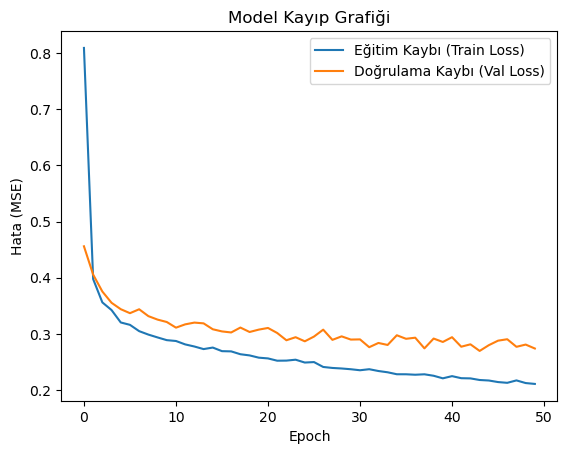

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Eğitim Kaybı (Train Loss)')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı (Val Loss)')
plt.title('Model Kayıp Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Hata (MSE)')
plt.legend()
plt.show()

Öğrenme Verimliliği: Eğitim kaybı (Loss) 0.80'den 0.21'e istikrarlı şekilde düşmüştür. Bu, model mimarisinin (Dense katmanların) verideki örüntüleri çözmek için yeterli olduğunu gösterir.

Genelleme Yeteneği: Loss (0.21) ve Val_Loss (0.27) değerleri birbirine yakındır. Bu durum, modelin ezberlemediğini (Overfitting yapmadığını) ve yeni verilere uyum sağlayabildiğini kanıtlar.

Doyum Noktası: 40. epoch'tan itibaren hata düşüş hızı yavaşlamıştır; yani 50 epoch bu veri seti için ideal eğitim süresidir.

In [13]:
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Test verisi üzerinden tahminleri alalım
y_pred = model.predict(X_test)

# 2. Hata metriklerini hesaplayalım
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Test Sonuçları ---")
print(f"Ortalama Mutlak Hata (MAE): {mae:.4f}")
print(f"R-Kare (R2) Skoru: {r2:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 239us/step
--- Model Test Sonuçları ---
Ortalama Mutlak Hata (MAE): 0.3350
R-Kare (R2) Skoru: 0.8022


R2 Skoru (0 ile 1 arası): 1'e ne kadar yakınsa modelin o kadar başarılıdır. Örneğin 0.75 çıkarsa, "Modelim ev fiyatlarındaki değişimin %75'ini doğru tahmin edebiliyor" diyebilirsin.

MAE: Tahminlerinin ortalama ne kadar saptığını gösterir. 

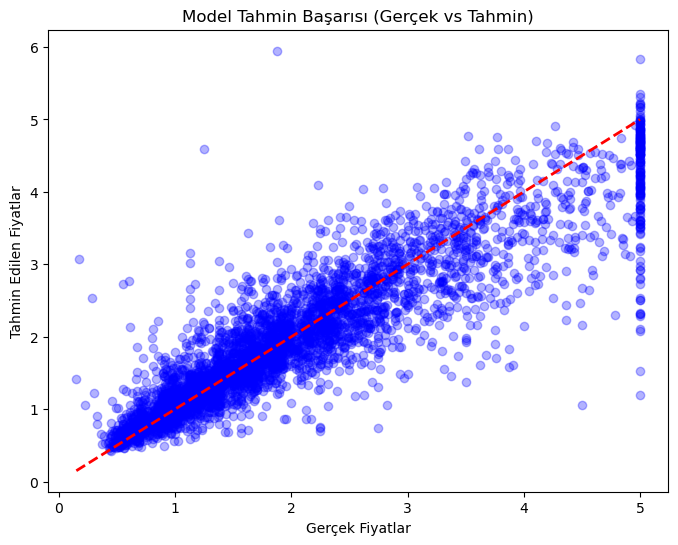

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Gerçek Fiyatlar')
plt.ylabel('Tahmin Edilen Fiyatlar')
plt.title('Model Tahmin Başarısı (Gerçek vs Tahmin)')
plt.show()

ExactExplainer explainer: 101it [00:12,  3.36it/s]                        


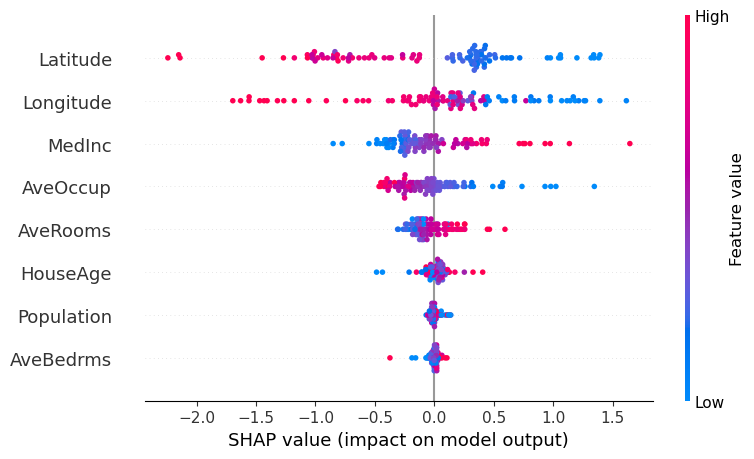

In [ ]:
import shap

#shap nedir? SHAP (SHapley Additive exPlanations), makine öğrenimi modellerinin kararlarını açıklamak için kullanılan bir yöntemdir. 
# SHAP, her bir özelliğin modelin tahminine ne kadar katkıda bulunduğunu ölçer ve bu katkıları görselleştirir. 
# SHAP, özellikle karmaşık modellerin anlaşılmasını kolaylaştırır ve modelin hangi özelliklere daha fazla önem verdiğini gösterir.

# Modelin kararlarını analiz etmek için bir 'explainer' oluşturuyoruz
# Not: Eğitim setinden küçük bir örneklem (örneğin 100 veri) kullanmak işlemi hızlandırır
explainer = shap.Explainer(model, X_train[:100])
shap_values = explainer(X_test[:100])

# Görselleştirme: Hangi özellik fiyatı ne yönde etkiliyor?
shap.summary_plot(shap_values, X_test[:100], feature_names=housing.feature_names)

1. En Önemli Özellikler: Konum (Latitude & Longitude)
Grafiğin en üstünde Latitude ve Longitude var. Bu şu demek: Modelin, evin fiyatını belirlerken en çok konuma bakıyor.

Latitude (Enlem): Kırmızı noktalar (yüksek enlem değerleri) sol tarafta toplanmış. Yani enlem arttıkça (Kuzeye gidildikçe) bu veri setinde fiyatlar düşme eğilimi gösteriyor.

Longitude (Boylam): Mavi noktalar (düşük boylam değerleri) sağ tarafta. Bu da belirli bir boylam aralığının fiyatı ciddi şekilde artırdığını gösteriyor. California için bu, kıyı şeridine yakınlığı temsil eder.

2. Gelir Etkisi (MedInc)
Üçüncü sıradaki MedInc modelin "mantıklı" öğrendiğinin kanıtıdır:

Kırmızı noktalar sağda: Bölgedeki medyan gelir arttıkça (kırmızı), SHAP değeri pozitif oluyor. Yani model, gelir yüksekse "bu ev pahalıdır" diyor.

Mavi noktalar solda: Gelir düşükse fiyat tahmini aşağı çekiliyor.

3. Hane Halkı Yoğunluğu (AveOccup)
Burada ilginç bir durum var:

Mavi noktalar sağa doğru yayılmış: Düşük hane halkı yoğunluğu (yani evde az kişinin yaşaması), fiyatı artıran bir faktör olarak görülüyor. Evde yaşayan kişi sayısı arttıkça (kırmızı noktalar solda), fiyat tahmini düşüyor.

4. Daha Az Önemli Faktörler
Grafiğin en altındaki Population ve AveBedrms özelliklerine bakarsan, noktaların "sıfır" hattında çok sıkıştığını görürsün.

Yorum: Modelin bu özellikleri fiyatı tahmin ederken neredeyse hiç önemsemiyor. Tezin için "Nüfus yoğunluğu, konut fiyatı üzerinde bu model özelinde anlamlı bir fark yaratmamıştır" diyebilirsin.

Grafiği okurken şu 3 temel eksene odaklanmalısın:

1. Dikey Eksen (Y-Ekseni): Özellik Önem Sırası
Yukarıdan Aşağıya: Özellikler, modelin tahmini üzerindeki toplam etkisine göre sıralanır.

En üstteki değişken (muhtemelen MedInc), modelin fiyatı belirlerken en çok güvendiği değişkendir. Aşağılara indikçe değişkenlerin önemi azalır.

2. Renkler: Özelliğin Değeri
Kırmızı: O özelliğin değerinin yüksek olduğunu (Örneğin: Gelir çok yüksek).

Mavi: O özelliğin değerinin düşük olduğunu (Örneğin: Ev çok eski).

Renk geçişleri (mordan kırmızıya), değerin kademeli olarak arttığını gösterir.

3. Yatay Eksen (X-Ekseni): Tahmine Etki (SHAP Value)
Sıfırın Sağ Tarafı (+): Bu bölgedeki noktalar, fiyat tahminini artıran etkilerdir.

Sıfırın Sol Tarafı (-): Bu bölgedeki noktalar, fiyat tahminini düşüren etkilerdir.

In [21]:
# 8 özelliği de içeren yeni ev verisi (Sıralama kritiktir!)
# Örnek: Gelir 5.0, Yaş 20, Oda 5.2, Y.Odası 1.0, Nüfus 1500, Hane 3.0, Enlem 34.2, Boylam -118.4
yeni_ev = np.array([[5.0, 20.0, 5.2, 1.0, 1500.0, 3.0, 34.2, -118.4]])

# DİKKAT: Modeli eğitirken kullandığın 'scaler' objesini burada mutlaka kullanmalısın.
# Model ham rakamları değil, ölçeklenmiş rakamları anlar.
yeni_ev_scaled = scaler.transform(yeni_ev)

# Tahmin yap
tahmin = model.predict(yeni_ev_scaled)

print(f"Modelin bu ev için fiyat tahmini: {tahmin[0][0]:.4f} (100k $ biriminde)")
print(f"Gerçekçi Fiyat Tahmini: ${tahmin[0][0] * 100000:,.0f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Modelin bu ev için fiyat tahmini: 2.5238 (100k $ biriminde)
Gerçekçi Fiyat Tahmini: $252,375


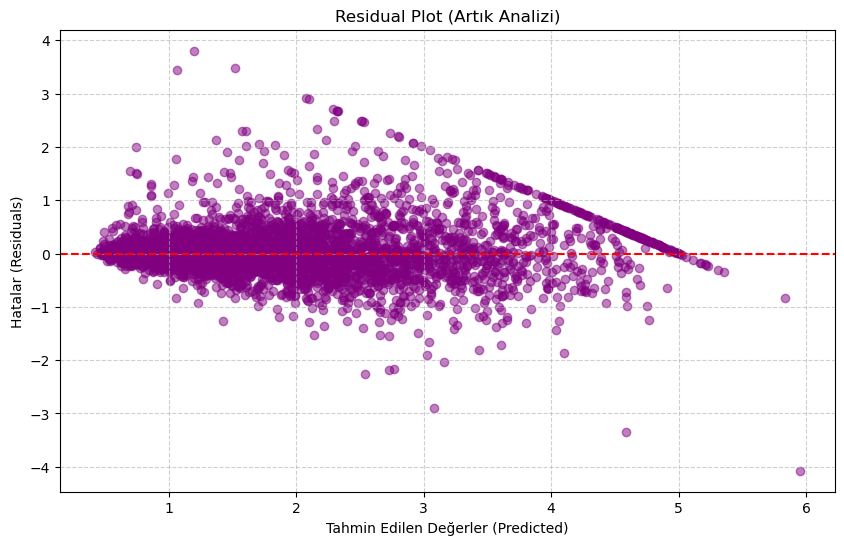

In [23]:
# 1. Artıkları (Residuals) hesapla: Gerçek Değer - Tahmin Edilen Değer
residuals = y_test - y_pred.flatten()

# 2. Grafiği çiz
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='r', linestyle='--') # Sıfır çizgisi (ideal durum)
plt.xlabel('Tahmin Edilen Değerler (Predicted)')
plt.ylabel('Hatalar (Residuals)')
plt.title('Residual Plot (Artık Analizi)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

1. Rastgele Dağılım (İdeal Durum)
Eğer noktalar kırmızı sıfır çizgisinin etrafına rastgele ve eşit şekilde dağılmışsa, modelin verideki tüm bilgiyi öğrenmiş demektir. Bu, modelinin "tarafsız" olduğunu gösterir.

2. Huni Şekli (Heteroscedasticity)
Eğer noktalar tahmin edilen değerler arttıkça (sağa doğru) bir huni gibi açılıyorsa, modelin düşük fiyatlı evleri iyi tahmin ediyor ama yüksek fiyatlı evlerde çok yanılıyor demektir.

Tez notu: "Model yüksek fiyat segmentinde varyansı açıklamakta zorlanmaktadır."

3. Belirgin Bir Şekil (Curve/Kavis)
Eğer noktalar düz değil de "U" veya "S" gibi bir şekil oluşturuyorsa, modelin verideki doğrusal olmayan (non-linear) ilişkiyi tam olarak yakalayamadığı anlamına gelir. Bu durumda modelin derinliğini (katman sayısını) artırmak çözüm olabilir.

California Housing veri setinde ev fiyatları 5.0 (500.000$) değerinde sınırlandırılmıştır. Yani değeri 800 bin dolar veya 1 milyon dolar olan evler de veri setine "5.0" olarak kaydedilmiştir.Grafikte gördüğün o düz diyagonal çizgi, gerçek fiyatı 5.0 olan evlere aittir.Formül: $Artık (Residual) = Gerçek Değer (5.0) - Tahmin Edilen$Tahmin değerin arttıkça ($x$ ekseni), hata payın ($y$ ekseni) matematiksel olarak bu çizgi üzerinde kalmak zorunda kalıyor.